In [16]:
import pandas as pd
import os
from pathlib import Path
from transcript import CustomerTranscriptFactory
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from typing import Literal

In [2]:
os.getcwd()

'/app/src/sentiment_classification'

## Load Transcript Data

In [3]:
transcripts_path = "./data/transcripts_v3/"

In [4]:
transcripts = CustomerTranscriptFactory().from_folder(transcripts_path)

In [12]:
transcript_df = pd.DataFrame([transcript.model_dump() for transcript in transcripts])`

In [13]:
transcript_df.head()

,file_name,text,agent_transcript,customer_transcript
0,data/transcripts_v3/transcript_38.txt,"Member: Hi, I'm calling to get a case pre-auth...","\nPA Agent: Thank you for calling, Emily. Can ...","Member: Hi, I'm calling to get a case pre-auth..."
1,data/transcripts_v3/transcript_10.txt,"Member: Hi, I'm calling to schedule an appoint...","\nCustomer Support: Hi Emily, thank you for ca...","Member: Hi, I'm calling to schedule an appoint..."
2,data/transcripts_v3/transcript_138.txt,"Member: Hi, I'm calling to get a case pre-auth...","\nPA Agent: Hi Emily, thank you for calling PA...","Member: Hi, I'm calling to get a case pre-auth..."
3,data/transcripts_v3/transcript_104.txt,"Member: Hi, I'm calling to get a case pre-auth...",\nAgent: Thank you for calling PA customer car...,"Member: Hi, I'm calling to get a case pre-auth..."
4,data/transcripts_v3/transcript_110.txt,"Member: Hi, I'm calling about a denied claim I...","\nCustomer Support: Hi Emily, sorry to hear th...","Member: Hi, I'm calling about a denied claim I..."


#### Load the transcript classification based on customer side of transcript

In [5]:
classifications_customer = pd.read_json("./classifications_customer.json")

#### Load the transcript classification using all of the transcript

In [6]:
classifications_full = pd.read_json("./classifications_full.json")

In [7]:
classifications_customer

,file_name,chain_of_thought,sentiment,follow_up_action
0,../data/transcripts_v3/transcript_38.txt,"The customer, Emily Wilson, initiated the call...",positive,issue_resolved
1,../data/transcripts_v3/transcript_10.txt,"The customer, Emily, is expressing a clear req...",positive,issue_resolved
2,../data/transcripts_v3/transcript_138.txt,"The customer, Emily Wilson, expresses a clear ...",positive,issue_resolved
3,../data/transcripts_v3/transcript_104.txt,"The customer, Emily Wilson, is inquiring about...",positive,issue_resolved
4,../data/transcripts_v3/transcript_110.txt,"The customer, Emily Wilson, is expressing conc...",negative,follow_up_call_needed
...,...,...,...,...
195,../data/transcripts_v3/transcript_135.txt,"The customer, Emily Wilson, appears to be conf...",neutral,issue_resolved
196,../data/transcripts_v3/transcript_121.txt,"The customer, Emily Wilson, is making a proact...",neutral,follow_up_call_needed
197,../data/transcripts_v3/transcript_0.txt,"The customer, Emily, is seeking confirmation f...",positive,issue_resolved
198,../data/transcripts_v3/transcript_35.txt,The customer expresses frustration about being...,negative,follow_up_call_needed


## Analysis of Data

In [8]:
classifications_customer.sentiment.value_counts()

sentiment
positive    129
neutral      37
negative     34
Name: count, dtype: int64

In [32]:
joined_data = classifications_customer\
        .assign(file_name = lambda row: row['file_name'].str.replace("../", ""))\
        .merge(transcript_df, on="file_name")

In [ ]:
positive_customer_classifications.customer_transcript[5]

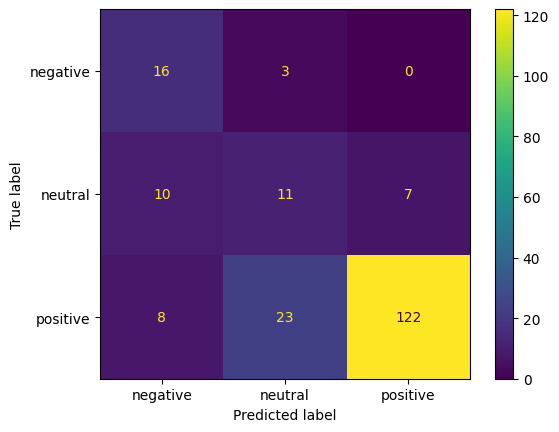

In [23]:
ConfusionMatrixDisplay.from_predictions(y_true=classifications_full.sentiment,
                                        y_pred=classifications_customer.sentiment)

In [34]:
sentiment_misclassifications = joined_data[classifications_full.sentiment != classifications_customer.sentiment]

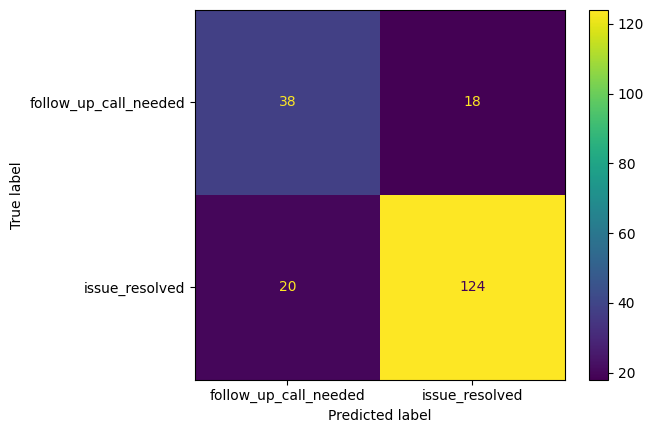

In [24]:
ConfusionMatrixDisplay.from_predictions(y_true=classifications_full.follow_up_action,
                                        y_pred=classifications_customer.follow_up_action)